In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

## 1.4 Designing a Sampling Plan
#### 1.4.1 Stratification

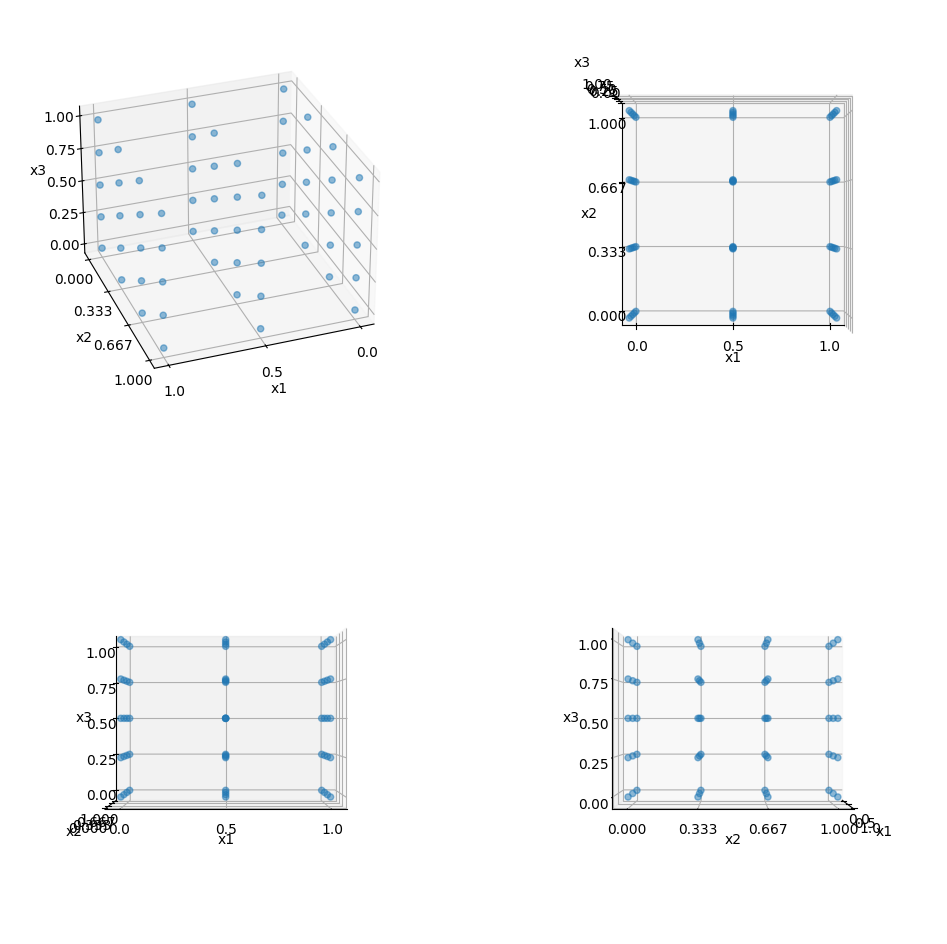

In [28]:
def full_factorial(q: list) -> None:

    if min(q) < 2:
        raise Exception("You must have at least two points per dimension")

    x1 = np.linspace(0,1,q[0])
    x2 = np.linspace(0,1,q[1])
    x3 = np.linspace(0,1,q[2])
    
    X1, X2, X3 = np.meshgrid(x1, x2, x3, indexing='ij')

    fig = plt.figure(figsize=(12, 12))

    elevations = [None, 90, 0, 0]
    azimuths   = [70, -90, -90, 0]

    for i, elev, azim in zip(range(1,5), elevations, azimuths):
        ax = fig.add_subplot(2,2,i, projection='3d')

        ax.xaxis.set_major_locator(MultipleLocator(1/(q[0]-1)))
        ax.xaxis.set_minor_locator(MultipleLocator(1/(q[0]-1)))

        ax.yaxis.set_major_locator(MultipleLocator(1/(q[1]-1)))
        ax.yaxis.set_minor_locator(MultipleLocator(1/(q[1]-1)))
        
        ax.zaxis.set_major_locator(MultipleLocator(1/(q[2]-1)))
        ax.zaxis.set_minor_locator(MultipleLocator(1/(q[2]-1)))
        
        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_zlabel('x3')
        ax.scatter(X1, X2, X3, alpha=0.5)

        ax.view_init(elev=elev, azim=azim)
        ax.set_box_aspect(None, zoom=0.85)

    plt.show()

full_factorial([3,4,5])

Translated code from book. Chose to just use np meshgrids to avoid some loops

#### 1.4.2 Latin Squares and Random Latin Hypercubes

[[ 0.97  0.11  0.31]
 [ 0.91  0.35  0.69]
 [ 0.77  0.81  0.45]
 [ 0.03  0.43  0.83]
 [ 0.89  0.83  0.85]
 [ 0.65  0.67  0.63]
 [ 0.11  0.05  0.03]
 [ 0.93  0.71  0.37]
 [ 0.71  0.15  0.01]
 [ 0.73  0.25  0.09]
 [ 0.07  0.75  0.51]
 [ 0.41  0.91  0.91]
 [ 0.37  0.29  0.27]
 [ 0.21  0.23  0.61]
 [ 0.59  0.53  0.81]
 [ 0.35  0.37  0.47]
 [ 0.39  0.31  0.87]
 [ 0.53  0.55  0.65]
 [ 0.13  0.17  0.39]
 [ 0.95  0.87 -0.01]
 [ 0.43 -0.01  0.05]
 [ 0.55  0.89  0.71]
 [ 0.57  0.07  0.35]
 [ 0.19  0.01  0.13]
 [ 0.83  0.59  0.93]
 [ 0.47  0.79  0.33]
 [ 0.85  0.63  0.11]
 [ 0.29  0.19  0.57]
 [ 0.09  0.97  0.15]
 [ 0.49  0.27  0.25]
 [ 0.17  0.03  0.59]
 [ 0.51  0.69  0.29]
 [ 0.05  0.39  0.67]
 [ 0.27  0.45  0.17]
 [-0.01  0.09  0.89]
 [ 0.75  0.33  0.79]
 [ 0.23  0.47  0.77]
 [ 0.81  0.51  0.19]
 [ 0.69  0.49  0.73]
 [ 0.67  0.77  0.53]
 [ 0.45  0.13  0.75]
 [ 0.33  0.61  0.43]
 [ 0.25  0.93  0.23]
 [ 0.61  0.41  0.55]
 [ 0.87  0.85  0.95]
 [ 0.01  0.21  0.97]
 [ 0.15  0.57  0.49]
 [ 0.31  0.65

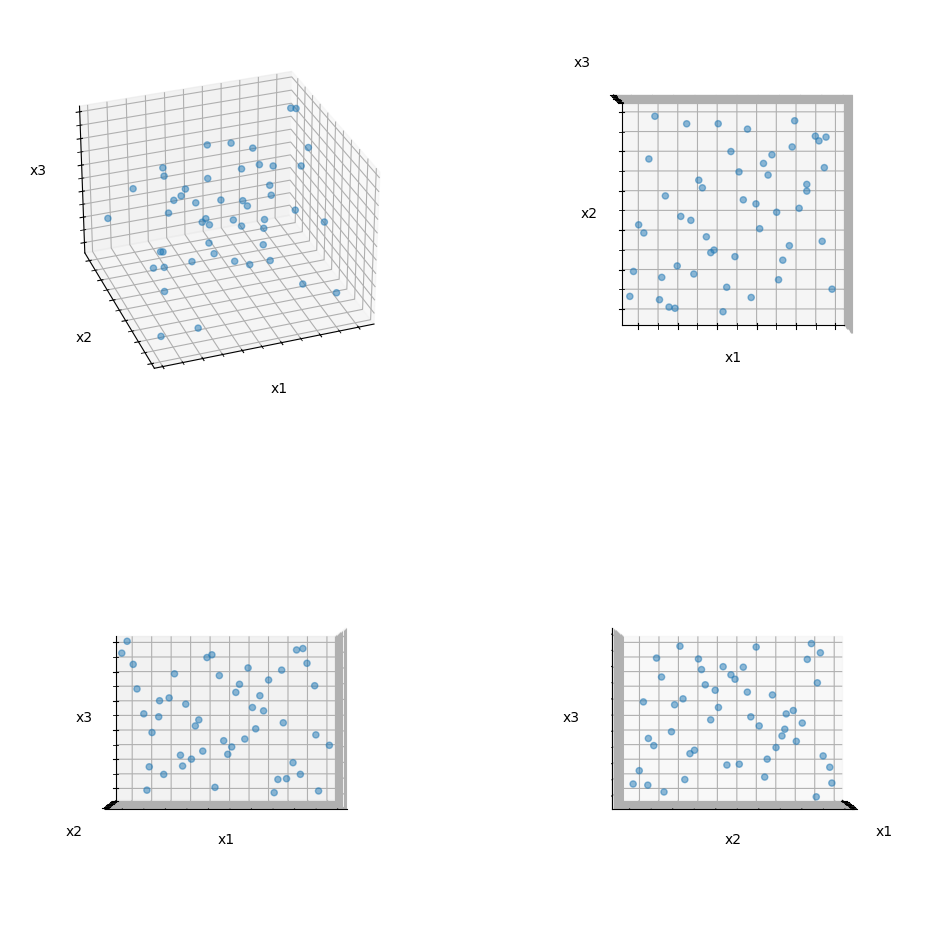

In [33]:
def random_latin_hypercube(n:int, k:int, edges:int = 0) -> None:

    rng = np.random.default_rng()

    X = np.zeros((n,k))

    for i in range(k):
        X[:,i] = rng.permutation(n)

    if edges == 1:
        X = (X-1)/(n-1);
    else:
        X = (X-0.5)/n;
    
    print(X)

    X1 = X[:,0]
    X2 = X[:,1]
    X3 = X[:,2]

    fig = plt.figure(figsize=(12, 12))

    elevations = [None, 90, 0, 0]
    azimuths   = [70, -90, -90, 0]

    for i, elev, azim in zip(range(1,5), elevations, azimuths):
        ax = fig.add_subplot(2,2,i, projection='3d')

        ax.xaxis.set_minor_locator(MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(MultipleLocator(0.1))
        ax.zaxis.set_minor_locator(MultipleLocator(0.1))

        ax.set_xlabel('x1')
        ax.set_ylabel('x2')
        ax.set_zlabel('x3')
        
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_zticklabels([])

        ax.scatter(X1, X2, X3, alpha=0.5)

        ax.view_init(elev=elev, azim=azim)
        ax.set_box_aspect(None, zoom=0.85)

    plt.show()

random_latin_hypercube(50,3)